# 06 — CUPED: variance reduction

**Purpose.** Try to buy precision without buying customers, and report honestly how
much that is worth here.

Feature 5 left a concrete problem. Detecting a 10% improvement in spend needs roughly
**23x** the customers this experiment had. You cannot always acquire more customers,
but the sample size is only one side of the inequality. Precision depends on the ratio
of noise to sample:

$$\text{standard error} = \sqrt{\frac{\sigma^2_{\text{treated}} + \sigma^2_{\text{control}}}{n}}$$

CUPED attacks the numerator. It subtracts off the part of the outcome that a
pre-experiment covariate already explains:

$$Y_{\text{cuped}} = Y - \theta\,(X - \bar{X}), \qquad \theta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

Because `X` is measured *before* treatment, subtracting it cannot bias anything — the
adjustment has mean zero, so the expected effect is unchanged while the noise around
it falls.

**The entire benefit is one number.** The variance removed is exactly ρ², the squared
correlation between outcome and covariate. That is an identity, not a rule of thumb,
and it means CUPED cannot be argued into working. Either a well-correlated pre-period
covariate exists, or the technique has nothing to offer.

This notebook finds that it has almost nothing to offer here, and explains precisely
why.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.load import load_processed
from src.analysis.cuped import (
    run_cuped_analysis, cuped_effect, ancova_effect,
    apply_cuped, variance_reduction, cupac_covariate,
)

pd.set_option("display.width", 150)
df = load_processed()

## 1. First, does the implementation work?

Since the result on real data is going to be a null one, that question has to be
settled first. A technique that delivers nothing and a technique that is coded wrong
look identical from the outside.

So: synthetic experiments where the correlation is *known by construction*. If CUPED
recovers the theoretical variance reduction there, its failure on real data is a fact
about the data.

In [2]:
def synthetic(rho, n=200_000, effect=0.0, seed=1):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, n)
    y = rho * x + np.sqrt(1 - rho**2) * rng.normal(0, 1, n)
    treated = rng.random(n) < 0.5
    return x, y + effect * treated, treated

rows = []
for rho in [0.1, 0.3, 0.5, 0.7, 0.9]:
    x, y, _ = synthetic(rho)
    realised = variance_reduction(y, apply_cuped(y, x))
    rows.append({
        "correlation (true)": rho,
        "theoretical rho^2": rho**2,
        "realised reduction": realised,
        "equivalent sample": 1 / (1 - realised),
    })

pd.DataFrame(rows).style.format({
    "correlation (true)": "{:.2f}",
    "theoretical rho^2": "{:.1%}",
    "realised reduction": "{:.1%}",
    "equivalent sample": "{:.2f}x",
}).hide(axis="index")

correlation (true),theoretical rho^2,realised reduction,equivalent sample
0.10,1.0%,1.0%,1.01x
0.30,9.0%,9.0%,1.10x
0.50,25.0%,25.0%,1.33x
0.70,49.0%,49.0%,1.96x
0.90,81.0%,81.0%,5.27x


The implementation recovers ρ² to three decimal places at every correlation. **The
machinery is correct.**

The rightmost column is the practical translation. Precision scales with √n, so
cutting variance by a fraction *v* is worth multiplying the sample by 1/(1−v). A
covariate correlating at 0.7 is worth nearly doubling the customer base — which is the
reason CUPED is standard practice at companies running continuous experimentation.

## 2. Now the real data

The covariate is `history`, prior customer spend. It is the only pre-treatment
variable in this dataset that plausibly predicts future spend.

In [3]:
correlations = pd.DataFrame({
    outcome: {
        covariate: np.corrcoef(df[outcome].astype(float),
                               df[covariate].astype(float))[0, 1]
        for covariate in ["history", "log_history", "recency", "history_segment_rank"]
    }
    for outcome in config.OUTCOMES
})

print("Correlation with each outcome:")
display(correlations.style.format("{:+.4f}"))
print("\nImplied variance reduction (rho^2):")
display((correlations ** 2).style.format("{:.3%}"))

Correlation with each outcome:


,visit,conversion,spend
history,+0.0652,+0.0294,+0.0217
log_history,+0.0688,+0.0256,+0.0147
recency,-0.0748,-0.0244,-0.0163
history_segment_rank,+0.0697,+0.0284,+0.0192



Implied variance reduction (rho^2):


,visit,conversion,spend
history,0.424%,0.086%,0.047%
log_history,0.474%,0.066%,0.022%
recency,0.559%,0.060%,0.027%
history_segment_rank,0.486%,0.081%,0.037%


**The best correlation in the entire dataset is 0.075.** Squared, that is a 0.56%
variance reduction. For spend — the outcome that most needs help — `history`
correlates at **0.021**, worth **0.04%**.

## 3. Applying CUPED anyway

Including CUPAC, the generalisation that replaces the single covariate with a
gradient-boosted model's prediction of the outcome from *all* pre-treatment features.
Predictions are generated out-of-fold: a model scored on rows it trained on has
already seen their outcomes, and would track their noise rather than their predictable
part, overstating the reduction.

In [4]:
table = run_cuped_analysis(df, save=False)

table[[
    "treatment_arm", "outcome", "covariate", "correlation",
    "realised_variance_reduction", "ci_narrowing", "equivalent_sample_multiplier",
]].style.format({
    "correlation": "{:+.4f}",
    "realised_variance_reduction": "{:.3%}",
    "ci_narrowing": "{:.3%}",
    "equivalent_sample_multiplier": "{:.4f}x",
}).hide(axis="index")

treatment_arm,outcome,covariate,correlation,realised_variance_reduction,ci_narrowing,equivalent_sample_multiplier
Mens E-Mail,visit,history,+0.0667,0.444%,0.222%,1.0045x
Mens E-Mail,visit,CUPAC (all covariates),+0.1594,2.555%,1.286%,1.0262x
Mens E-Mail,conversion,history,+0.0298,0.088%,0.044%,1.0009x
Mens E-Mail,conversion,CUPAC (all covariates),+0.0290,0.083%,0.042%,1.0008x
Mens E-Mail,spend,history,+0.0209,0.043%,0.022%,1.0004x
Mens E-Mail,spend,CUPAC (all covariates),+0.0139,0.019%,0.009%,1.0002x
Womens E-Mail,visit,history,+0.0633,0.400%,0.200%,1.0040x
Womens E-Mail,visit,CUPAC (all covariates),+0.1542,2.389%,1.202%,1.0245x
Womens E-Mail,conversion,history,+0.0260,0.068%,0.034%,1.0007x
Womens E-Mail,conversion,CUPAC (all covariates),+0.0213,0.045%,0.023%,1.0005x


**The best result in the table is a 2.6% variance reduction**, for visit under
CUPAC. Feature 5 said spend needs 23x more customers; CUPED offers **1.0004x**.

Two details worth noticing:

**CUPAC helps on visit and *hurts* on spend.** Pooling all covariates raises the visit
correlation from 0.067 to 0.159 — a six-fold gain in variance reduction. But on spend
it falls from 0.021 to 0.014. That is not a bug. When there is essentially no signal to
find, a flexible model's out-of-fold predictions are mostly fitted noise, and they
correlate with the outcome *less* than the raw covariate does. A more powerful method
is not automatically a better one.

**The effect estimates barely move.** They shift slightly because the CUPED estimator
also corrects for residual covariate imbalance between arms — and Feature 3 showed
that imbalance is tiny, so the correction is tiny too. The two features agree, which
is a useful consistency check on both.

In [5]:
single = table[table["covariate"] == config.CUPED_COVARIATE]
single[[
    "treatment_arm", "outcome", "effect_raw", "effect_cuped",
    "ci_low_raw", "ci_high_raw", "ci_low_cuped", "ci_high_cuped",
]].style.format({
    "effect_raw": "{:+.5f}", "effect_cuped": "{:+.5f}",
    "ci_low_raw": "{:+.4f}", "ci_high_raw": "{:+.4f}",
    "ci_low_cuped": "{:+.4f}", "ci_high_cuped": "{:+.4f}",
}).hide(axis="index")

treatment_arm,outcome,effect_raw,effect_cuped,ci_low_raw,ci_high_raw,ci_low_cuped,ci_high_cuped
Mens E-Mail,visit,+0.07659,+0.07641,+0.0700,+0.0832,+0.0698,+0.0830
Mens E-Mail,conversion,+0.00681,+0.00678,+0.0050,+0.0086,+0.0050,+0.0086
Mens E-Mail,spend,+0.76983,+0.76744,+0.4851,+1.0545,+0.4828,+1.0521
Womens E-Mail,visit,+0.04523,+0.04509,+0.0389,+0.0516,+0.0388,+0.0514
Womens E-Mail,conversion,+0.00311,+0.00310,+0.0015,+0.0047,+0.0015,+0.0047
Womens E-Mail,spend,+0.42441,+0.42270,+0.1690,+0.6799,+0.1673,+0.6781


## 4. Why it fails here

CUPED works when you have **the same metric, measured on the same user, in a period
before the experiment**. Last week's spend predicts this week's spend because spending
is persistent at the individual level — correlations of 0.5 to 0.9 are routine, which
is 25% to 81% variance reduction.

`history` is not that. It is lifetime historical spend, over an unspecified window,
already coarsely bucketed. It says something about a customer's general value but very
little about whether they will buy *in the next two weeks*. And the outcome it must
predict is 99.1% zeros — nearly all of the variance lives in the rare, essentially
unpredictable event of someone deciding to purchase.

The gap between "a pre-period measurement of the outcome" and "a related attribute
measured at some point in the past" is the whole difference between CUPED working and
not working.

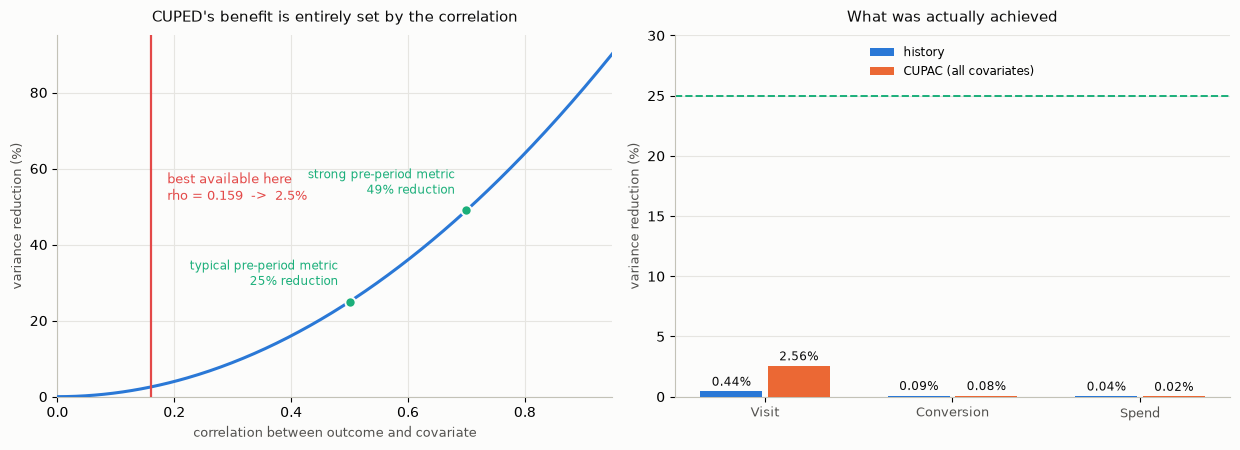

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
fig.patch.set_facecolor("#fcfcfb")

# --- Left: what variance reduction is available at each correlation ---
ax = axes[0]
ax.set_facecolor("#fcfcfb")
rho_grid = np.linspace(0, 0.95, 300)
ax.plot(rho_grid, rho_grid**2 * 100, color="#2a78d6", linewidth=2.2, zorder=3)

best = table["correlation"].abs().max()
ax.axvline(best, color="#e34948", linewidth=1.6, zorder=4)
ax.annotate(
    f"best available here\nrho = {best:.3f}  ->  {best**2:.1%}",
    (best, 55), xytext=(12, 0), textcoords="offset points",
    fontsize=9, color="#e34948", va="center",
)
for rho, label in [(0.5, "typical pre-period metric"), (0.7, "strong pre-period metric")]:
    ax.scatter([rho], [rho**2 * 100], s=55, color="#1baf7a", zorder=5,
               edgecolor="#fcfcfb", linewidth=1.4)
    ax.annotate(f"{label}\n{rho**2:.0%} reduction", (rho, rho**2 * 100),
                xytext=(-8, 12), textcoords="offset points",
                fontsize=8.5, color="#1baf7a", ha="right")

ax.set_xlabel("correlation between outcome and covariate", fontsize=9.5, color="#52514e")
ax.set_ylabel("variance reduction (%)", fontsize=9.5, color="#52514e")
ax.set_title("CUPED's benefit is entirely set by the correlation",
             fontsize=11, color="#0b0b0b", pad=10)
ax.set_xlim(0, 0.95)
ax.set_ylim(0, 95)
ax.grid(color="#e6e5e1", linewidth=0.8, zorder=0)

# --- Right: what was actually achieved, per outcome ---
ax = axes[1]
ax.set_facecolor("#fcfcfb")
COVARIATE_COLOURS = {"history": "#2a78d6", "CUPAC (all covariates)": "#eb6834"}

outcomes = config.OUTCOMES
width = 0.36
for offset, (covariate, colour) in zip([-width / 2, width / 2],
                                       COVARIATE_COLOURS.items()):
    values = [
        table[(table["outcome"] == o) & (table["covariate"] == covariate)]
        ["realised_variance_reduction"].max() * 100
        for o in outcomes
    ]
    positions = [i + offset for i in range(len(outcomes))]
    ax.bar(positions, values, width=width * 0.92, color=colour,
           label=covariate, zorder=3)
    for position, value in zip(positions, values):
        ax.annotate(f"{value:.2f}%", (position, value), xytext=(0, 4),
                    textcoords="offset points", ha="center",
                    fontsize=8.5, color="#0b0b0b")

ax.axhline(25, color="#1baf7a", linewidth=1.4, linestyle="--", zorder=2)
ax.annotate("25% - what a proper pre-period metric delivers",
            (len(outcomes) - 0.5, 25), xytext=(0, 5),
            textcoords="offset points", ha="right",
            fontsize=8.5, color="#1baf7a")

ax.set_xticks(range(len(outcomes)))
ax.set_xticklabels([o.capitalize() for o in outcomes], fontsize=9.5, color="#52514e")
ax.set_ylabel("variance reduction (%)", fontsize=9.5, color="#52514e")
ax.set_title("What was actually achieved", fontsize=11, color="#0b0b0b", pad=10)
ax.set_ylim(0, 30)
ax.legend(frameon=False, fontsize=8.5, loc="upper center")
ax.grid(axis="y", color="#e6e5e1", linewidth=0.8, zorder=0)

for axis in axes:
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("#c3c2b7")

fig.tight_layout()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "06_cuped_variance_reduction.png", dpi=150,
            bbox_inches="tight", facecolor="#fcfcfb")
plt.show()

## 5. CUPED and ANCOVA are the same thing

CUPED is often presented as a distinct technique from regression adjustment. It is
not. CUPED subtracts the linear projection of the outcome onto the covariate; OLS
partials the same projection out. With one covariate the two are asymptotically
identical, and θ is precisely the OLS slope of Y on X.

In [7]:
rows = []
for arm, control_arm in config.COMPARISONS:
    for outcome in config.OUTCOMES:
        cuped = cuped_effect(df, outcome, arm, control_arm=control_arm)
        ancova = ancova_effect(df, outcome, arm, control_arm=control_arm)
        rows.append({
            "arm": arm, "outcome": outcome,
            "CUPED effect": cuped.effect_cuped,
            "ANCOVA effect": ancova["effect"],
            "CUPED se": cuped.se_cuped,
            "ANCOVA se": ancova["se"],
        })

pd.DataFrame(rows).style.format({
    "CUPED effect": "{:+.6f}", "ANCOVA effect": "{:+.6f}",
    "CUPED se": "{:.6f}", "ANCOVA se": "{:.6f}",
}).hide(axis="index")

arm,outcome,CUPED effect,ANCOVA effect,CUPED se,ANCOVA se
Mens E-Mail,visit,+0.076411,+0.076412,0.003378,0.003378
Mens E-Mail,conversion,+0.006783,+0.006784,0.000920,0.000920
Mens E-Mail,spend,+0.767438,+0.767450,0.145215,0.145151
Womens E-Mail,visit,+0.045095,+0.045095,0.003228,0.003228
Womens E-Mail,conversion,+0.003097,+0.003097,0.000822,0.000822
Womens E-Mail,spend,+0.422701,+0.422705,0.130308,0.130232


Agreement to five or six decimal places. Knowing they are the same idea matters
practically: the regression form generalises to many covariates without any new theory,
which is exactly what CUPAC exploits.

## 6. What would it take to make this work?

The useful output of a negative result is a specification for fixing it. Here is what
each level of covariate quality would be worth, against Feature 5's requirement.

In [8]:
spend_mde_relative = 0.482          # from Feature 5
target_relative = 0.10              # a realistic business question
needed_multiplier = (spend_mde_relative / target_relative) ** 2

rows = []
for rho in [0.021, 0.10, 0.30, 0.50, 0.70, 0.90]:
    reduction = rho**2
    equivalent = 1 / (1 - reduction)
    rows.append({
        "covariate correlation": rho,
        "variance reduction": reduction,
        "equivalent sample": equivalent,
        "share of the 23x gap closed": equivalent / needed_multiplier,
    })

print(f"To detect a 10% relative effect on spend, Feature 5 requires "
      f"{needed_multiplier:.0f}x the sample.\n")
display(pd.DataFrame(rows).style.format({
    "covariate correlation": "{:.3f}",
    "variance reduction": "{:.1%}",
    "equivalent sample": "{:.2f}x",
    "share of the 23x gap closed": "{:.1%}",
}).hide(axis="index"))

To detect a 10% relative effect on spend, Feature 5 requires 23x the sample.



covariate correlation,variance reduction,equivalent sample,share of the 23x gap closed
0.021,0.0%,1.00x,4.3%
0.100,1.0%,1.01x,4.3%
0.300,9.0%,1.10x,4.7%
0.500,25.0%,1.33x,5.7%
0.700,49.0%,1.96x,8.4%
0.900,81.0%,5.26x,22.7%


Even a **0.9 correlation** — better than almost any real pre-period covariate —
delivers 5.3x effective sample, closing under a quarter of the gap. CUPED alone was
never going to solve the spend problem here; it would have made it materially cheaper.

## Conclusion

| | Result |
|---|---|
| Implementation correct? | Yes — recovers ρ² exactly on synthetic data |
| Best variance reduction achieved | 2.6% (visit, CUPAC) |
| Variance reduction on spend | 0.04% |
| Effective extra sample | 1.0004x, against the 23x needed |
| Conclusions changed | None |

**CUPED is correctly implemented and delivers essentially nothing on this dataset.**
The reason is specific and diagnosable: `history` is lifetime spend in a coarse bucket,
not a pre-period measurement of the outcome. Correlation 0.021 permits a 0.04% variance
reduction and no method can extract more, because the ceiling is an identity rather
than an implementation detail.

The actionable finding is about instrumentation rather than analysis: **to make future
experiments on spend viable, log each customer's spend in a fixed pre-experiment
window.** That single column would plausibly correlate 0.4–0.6 with the outcome and cut
variance by 16–36%, and it costs nothing but a table.

It is also worth stating what CUPED did *not* do. It did not change a single
conclusion from Feature 4 — every effect significant before adjustment is significant
after, with materially identical point estimates. That is the expected behaviour of a
correctly implemented variance-reduction technique on a dataset that offers it no
purchase.

**Next — Feature 7:** the effects so far are averages. An average positive effect is
entirely consistent with a substantial group of customers responding negatively.
Heterogeneous treatment effects go looking for exactly that.